In [211]:
from funcs.process_data_funcs import *
import xgboost as xgb 
from lightgbm import LGBMRegressor
from best_params import xgboost_params, lightgbm_params

def reverse_log_transformations(df, columns_to_transform,target):
    """
    Reverses log1p transformations applied to the specified columns with overflow protection.

    :param df: DataFrame to reverse the log transformation on.
    :param columns_to_transform: List of columns to reverse.
    :return: DataFrame with log transformation reversed.
    """
    # Define a maximum value to prevent overflow
    MAX_EXP_VALUE = 700  # This prevents np.exp from causing overflow

    for col in columns_to_transform:
        # Clip the values before applying expm1 to prevent overflow
        df[col] = np.where(df[col] > 0, np.expm1(np.clip(df[col] / 100, a_min=None, a_max=MAX_EXP_VALUE)), df[col])
        # Handle NaNs by forward-filling and backward-filling (optional, based on your workflow)
        df[col].fillna(method='ffill', inplace=True)
        df[col].fillna(method='bfill', inplace=True)
    

    return df
def reverse_transformed_data(y_pred, y_test, transformations,target):
    from sklearn.preprocessing import StandardScaler,PowerTransformer,RobustScaler,QuantileTransformer
    """
    Args:
        y_pred: The predictions of our model, to be reversed back to
                the form of original data, for the mse calculation to be performed.
        y_test: The actual transformed data.
        transformations: A list containing strings, listing all transformations
                         applied to a certain dataset/file.
    """
    raw_data = pd.read_csv('data/raw/raw_data.csv',index_col='Date',parse_dates=True)

    # First, we convert all our data to series

    y_pred = pd.Series(y_pred,index=y_test.index)
    y_test = pd.Series(y_test,index=y_test.index)

    # 16. Soft Clipping for Outliers
    if 'soft_clipping' in transformations:
        threshold = 10  # Set an appropriate threshold
        y_test = reverse_soft_clipping(y_test, threshold,target)
        y_pred = reverse_soft_clipping(y_pred, threshold,target)

    # 15. Local Smoothing Before Logging
    if 'local_smooth' in transformations:
        skip = 'yes'
        # We cannot really reverse local smoothing, so skip it.

    # 14. Relative Transformations (Normalized Differences)
    if 'relative_transform' in transformations:
        y_test = reverse_relative_transform(y_test, target)
        y_pred = reverse_relative_transform(y_pred, target)

    # 13. Selective Log Transformation
    if 'selective_log' in transformations:
        threshold = 1.0  # Choose your threshold here
        y_test = reverse_selective_logging(y_test, threshold)
        y_pred = reverse_selective_logging(y_pred, threshold)

    # 12. Sliding Window Log Transformation
    if 'sliding_window_log' in transformations:
        y_test = reverse_sliding_window_log(y_test)
        y_pred = reverse_sliding_window_log(y_pred)

    # 11. Log All
    if 'log_all' in transformations:
        y_test = reverse_all_log_transformations(y_test)
        y_pred = reverse_all_log_transformations(y_pred)

    # 10. Power Transformer
    if 'power' in transformations:
        scaler = PowerTransformer()
        scaler.fit(raw_data[target].values.reshape(-1, 1))  # Fit on the original data
        y_test_transformed = scaler.inverse_transform(y_test.values.reshape(-1, 1)).flatten()  # Flatten the array
        y_pred_transformed = scaler.inverse_transform(y_pred.values.reshape(-1, 1)).flatten()  # Flatten the array

        y_test = pd.Series(y_test_transformed, index=y_test.index)
        y_pred = pd.Series(y_pred_transformed, index=y_pred.index)

    # 9. Quantile Transformer
    if 'quantile' in transformations:
        scaler = QuantileTransformer(n_quantiles=min(len(raw_data), 1000))
        scaler.fit(raw_data[target].values.reshape(-1, 1))  # Fit on the original data
        y_test_transformed = scaler.inverse_transform(y_test.values.reshape(-1, 1)).flatten()  # Flatten the array
        y_pred_transformed = scaler.inverse_transform(y_pred.values.reshape(-1, 1)).flatten()  # Flatten the array

        y_test = pd.Series(y_test_transformed, index=y_test.index)
        y_pred = pd.Series(y_pred_transformed, index=y_pred.index)


    # 8. Robust Scaler
    if 'robust' in transformations:
        scaler = RobustScaler()
        scaler.fit(raw_data[target].values.reshape(-1,1))  # Fit on the original data
        y_test_transformed = scaler.inverse_transform(y_test.values.reshape(-1,1)).flatten()
        y_pred_transformed = scaler.inverse_transform(y_pred.values.reshape(-1,1)).flatten()

        y_test = pd.Series(y_test_transformed,index=y_test.index)
        y_pred = pd.Series(y_pred_transformed,index=y_pred.index)



    # 7. Cap outliers
    if 'cap' in transformations:
        skip = 'yes'
        # We can't really do anything here.

    # 6. Apply ADF-based transformations
    if 'adf' in transformations:
        y_pred = reverse_best_transformations(y_pred, raw_data, target)
        y_test = reverse_best_transformations(y_test, raw_data, target)

    if 'pct_change' in transformations:
        initial_value = raw_data[target].iloc[0]
        
        # Apply safe_cumprod with overflow handling
        y_pred_reversed_series = safe_cumprod(y_pred + 1) * initial_value
        y_test_reversed_series = safe_cumprod(y_test + 1) * initial_value
        
        # Fill missing values (forward-fill and backward-fill)

        y_pred = y_pred.ffill()
        y_test = y_test.ffill()
        
    # 4. Standardize/Normalize the Data
    if 'scale' in transformations:
        raw_data = pd.read_csv("data/raw/raw_data.csv", parse_dates=True, index_col='Date')
        scaler = StandardScaler()
        scaler.fit(raw_data[target].values.reshape(-1,1))  # Fit on the original data
        y_test_transformed = scaler.inverse_transform(y_test.values.reshape(-1,1)).flatten()
        y_pred_transformed = scaler.inverse_transform(y_pred.values.reshape(-1,1)).flatten()

        y_test = pd.Series(y_test_transformed,index=y_test.index)
        y_pred = pd.Series(y_pred_transformed,index=y_pred.index)
  
    # 3. Apply logarithmic transformations
    if 'log' in transformations and 'log_all' not in transformations:
        print("Arrived to 'log' in applying log transformations:")
        print(f"columns y_test: {y_test}")
        try:
            columns_to_transform = [
                'GDP', 'PCE', 'PRFI', 'PNFI', 'EXPGS', 'IMPGS',
                'GCE', 'FGCE', 'HOUST', 'DSPI', 'M1', 'M1V', 'M2',
                'WTISPLC'
            ]
            y_pred = reverse_log_transformations(y_pred, columns_to_transform, target)
            y_test = reverse_log_transformations(y_test, columns_to_transform, target)
        except KeyError:
            if target in columns_to_transform:
                MAX_EXP_VALUE = 700  # This prevents np.exp from causing overflow
                y_pred =  np.where(y_pred > 0, np.expm1(np.clip(y_pred / 100, a_min = None, a_max = MAX_EXP_VALUE)), y_pred)   # Define a maximum value to prevent overflow
                
                y_pred = pd.Series(y_pred,index=y_test.index)
                y_pred.fillna(method='ffill',inplace=True)
                y_pred.fillna(method='bfill',inplace=True)

                # y_test =  np.where(y_test > 0, np.expm1(np.clip(y_test / 100, a_min = None, a_max = MAX_EXP_VALUE)), y_test)   # Define a maximum value to prevent overflow
                
                # y_test.fillna(method='ffill',inplace=True)
                # y_test.fillna(method='bfill',inplace=True)
        print("COMPLETED 'LOG'")


    # 2. Deflate nominal values
    if 'deflate' in transformations:
        cpi_col_name = 'CPIAUCSL'
        columns_to_deflate = [
            'GDP', 'PCE', 'PRFI', 'PNFI', 'EXPGS', 'IMPGS', 'GCE',
            'FGCE', 'DSPI'
        ]
        y_pred = reverse_deflate_nominal_values(y_pred, raw_data, cpi_col_name, columns_to_deflate, target)
        y_test = reverse_deflate_nominal_values(y_test, raw_data, cpi_col_name, columns_to_deflate, target)

    # 1. Impute missing values
    if 'impute' in transformations:
        skip = 'yes'
        # Since we cannot have NaN's, we will never reverse the imputation of data.

    y_pred = pd.Series(CubicSpline(y_pred.dropna().index, y_pred.dropna())(y_pred.index), index=y_pred.index)
    y_test = pd.Series(CubicSpline(y_test.dropna().index, y_test.dropna())(y_test.index), index=y_test.index)

    return y_pred, y_test

# SECOND IMPORTANT FUNCTION:
# Function to compute MSE scores and return predictions for both models
def compute_mse_scores_with_reversal(X_train, X_test, y_train, y_test,transformations,target):
    # X_train_scaled = X_train.dropna()
    # X_test_scaled = X_test.dropna()
    display(f"X_train nan: {X_train.isna().sum()}")
    X_train_scaled = X_train
    X_test_scaled = X_test

    mse_scores = {'XGBoost': [], 'LightGBM': []}
    train_mse_scores = {'XGBoost': [], 'LightGBM': []}
    predictions = {'XGBoost_train': None, 'XGBoost_test': None, 'LightGBM_train': None, 'LightGBM_test': None}
    reversed_train_mse_scores = {'XGBoost': [], 'LightGBM': []}
    reversed_mse_scores =  {'XGBoost': [], 'LightGBM': []}
    models = {
        'XGBoost': XGBRegressor(**xgboost_params),
        'LightGBM': LGBMRegressor(verbosity=-1,**lightgbm_params)
    }

    # Original:
    # for model_name, model in models.items():
    #     model.fit(X_train_scaled, y_train)
    #     predictions[f'{model_name}_train'] = model.predict(X_train_scaled)
    #     predictions[f'{model_name}_test'] = model.predict(X_test_scaled)
    #     train_mse_scores[model_name] = mean_squared_error(y_train, predictions[f'{model_name}_train'])
    #     mse_scores[model_name] = mean_squared_error(y_test, predictions[f'{model_name}_test'])

    # New: def reverse_transformed_data(y_pred, y_test, transformations,target):
    for model_name, model in models.items():
        model.fit(X_train_scaled, y_train)
        y_pred_train = model.predict(X_train_scaled)
        y_pred_test = model.predict(X_test_scaled)

        predictions[f'{model_name}_train'] = y_pred_train
        predictions[f'{model_name}_test'] = y_pred_test
        predictions[f'{model_name}_train_reversed'],X_train_reversed = reverse_transformed_data(y_pred_train, y_train, transformations,target)
        predictions[f'{model_name}_test_reversed'],X_test_reversed = reverse_transformed_data(y_pred_test,y_test,transformations,target)
        train_mse_scores[model_name] = mean_squared_error(y_train, predictions[f'{model_name}_train'])
        mse_scores[model_name] = mean_squared_error(y_test, predictions[f'{model_name}_test'])
        reversed_train_mse_scores[model_name] = mean_squared_error(y_train, predictions[f'{model_name}_train_reversed'])
        reversed_mse_scores[model_name] =  mean_squared_error(y_test, predictions[f'{model_name}_test_reversed'])
    aggregated_mse = sum(mse_scores.values()) / len(mse_scores)
    aggregated_reversed_mse = sum(reversed_mse_scores.values()) / len(reversed_mse_scores)
    return mse_scores,reversed_mse_scores, train_mse_scores,reversed_train_mse_scores, aggregated_mse, predictions


In [203]:
slash = "/"
day = 20
month = 11
year = 2022
print(f"{day}/{month}/{year}")

20/11/2022


In [ ]:
y

In [77]:
# Load data
processed_train_path = 'data/processed/train_transformed_combined.csv'
processed_test_path = 'data/processed/test_transformed_combined.csv'
tsfresh_train_path = 'data/tsfresh/train_combined_all_features_filled.csv'
tsfresh_test_path = 'data/tsfresh/test_combined_all_features_filled.csv'

train_combined = pd.read_csv(processed_train_path, index_col='Date', parse_dates=True)
test_combined = pd.read_csv(processed_test_path, index_col='Date', parse_dates=True)
tsfresh_features_train = pd.read_csv(tsfresh_train_path, index_col='Date', parse_dates=True)
tsfresh_features_test = pd.read_csv(tsfresh_test_path, index_col='Date', parse_dates=True)


# X_train['UNRATE__fft_coefficient__attr_angle__coeff_0']
display(tsfresh_features_train.columns)
display(tsfresh_features_train.head())
for col in tsfresh_features_train.columns:
    if str('UNRATE__fft_coefficient__attr_') in col:
        print(f"Str: UNRATE__fft_coefficient__attr_ found, full col name: {col} with a shape of {tsfresh_features_train[col].shape}")
# display(tsfresh_features_train['UNRATE__fft_coefficient__attr_""angle""__coeff_0'])

Index(['FEDFUNDS__variance_larger_than_standard_deviation',
       'FEDFUNDS__has_duplicate_max', 'FEDFUNDS__has_duplicate_min',
       'FEDFUNDS__has_duplicate', 'FEDFUNDS__sum_values',
       'FEDFUNDS__abs_energy', 'FEDFUNDS__median', 'FEDFUNDS__mean',
       'FEDFUNDS__length', 'FEDFUNDS__standard_deviation',
       ...
       'EXPGS__ratio_beyond_r_sigma__r_6', 'EXPGS__ratio_beyond_r_sigma__r_7',
       'EXPGS__ratio_beyond_r_sigma__r_10', 'EXPGS__count_above__t_0',
       'EXPGS__count_below__t_0', 'EXPGS__lempel_ziv_complexity__bins_2',
       'EXPGS__lempel_ziv_complexity__bins_3',
       'EXPGS__lempel_ziv_complexity__bins_5',
       'EXPGS__lempel_ziv_complexity__bins_10',
       'EXPGS__lempel_ziv_complexity__bins_100'],
      dtype='object', length=6082)

,FEDFUNDS__variance_larger_than_standard_deviation,FEDFUNDS__has_duplicate_max,FEDFUNDS__has_duplicate_min,FEDFUNDS__has_duplicate,FEDFUNDS__sum_values,FEDFUNDS__abs_energy,FEDFUNDS__median,FEDFUNDS__mean,FEDFUNDS__length,FEDFUNDS__standard_deviation,...,EXPGS__ratio_beyond_r_sigma__r_6,EXPGS__ratio_beyond_r_sigma__r_7,EXPGS__ratio_beyond_r_sigma__r_10,EXPGS__count_above__t_0,EXPGS__count_below__t_0,EXPGS__lempel_ziv_complexity__bins_2,EXPGS__lempel_ziv_complexity__bins_3,EXPGS__lempel_ziv_complexity__bins_5,EXPGS__lempel_ziv_complexity__bins_10,EXPGS__lempel_ziv_complexity__bins_100
Date,,,,,,,,,,,,,,,,,,,,,
1976-02-01,0.0,0.0,0.0,0.0,0.161211,0.025989,0.161211,0.161211,1.0,0.000000,...,0.0,0.0,0.0,0.0,1.0,1.000000,1.00,1.00,1.00,1.0
1976-03-01,0.0,0.0,0.0,0.0,0.064030,0.035433,0.032015,0.032015,2.0,0.129196,...,0.0,0.0,0.0,0.0,1.0,1.000000,1.00,1.00,1.00,1.0
1976-04-01,0.0,0.0,0.0,0.0,0.094785,0.036379,0.030755,0.031595,3.0,0.105490,...,0.0,0.0,0.0,0.0,1.0,0.666667,1.00,1.00,1.00,1.0
1976-05-01,0.0,0.0,0.0,0.0,-0.380434,0.262212,-0.033213,-0.095108,4.0,0.237713,...,0.0,0.0,0.0,0.0,1.0,0.500000,0.75,0.75,0.75,1.0
1976-06-01,0.0,0.0,1.0,1.0,-0.855652,0.488045,-0.097181,-0.171130,5.0,0.261387,...,0.0,0.0,0.0,0.0,1.0,0.400000,0.80,0.80,0.80,1.0


Str: UNRATE__fft_coefficient__attr_ found, full col name: UNRATE__fft_coefficient__attr_"real"__coeff_0 with a shape of (460,)
Str: UNRATE__fft_coefficient__attr_ found, full col name: UNRATE__fft_coefficient__attr_"imag"__coeff_0 with a shape of (460,)
Str: UNRATE__fft_coefficient__attr_ found, full col name: UNRATE__fft_coefficient__attr_"abs"__coeff_0 with a shape of (460,)
Str: UNRATE__fft_coefficient__attr_ found, full col name: UNRATE__fft_coefficient__attr_"angle"__coeff_0 with a shape of (460,)


In [84]:
# 1) Solving the string renaming issue
import re
columns = ["UNRATE__fft_coefficient__attr_""angle""__coeff_0",
"GCE__fft_coefficient__attr_""angle""__coeff_0",
"EXPGS__fft_coefficient__attr_""angle""__coeff_0"]
columns = ['UNRATE__fft_coefficient__attr_"angle"__coeff_0',
'GCE__fft_coefficient__attr_"angle"__coeff_0',
'EXPGS__fft_coefficient__attr_"angle"__coeff_0']
columns = ['UNRATE__fft_coefficient__attr_""angle""__coeff_0',
'GCE__fft_coefficient__attr_""angle""__coeff_0',
'EXPGS__fft_coefficient__attr_""angle""__coeff_0']
# print(f"columns now: {columns}")
for col in columns:
    print(f"col before sub: {col}")
    col = re.sub(str('""'),str('"'),col)
    print("col after sub:",col)
# COMPLETE

col before sub: UNRATE__fft_coefficient__attr_""angle""__coeff_0
col after sub: UNRATE__fft_coefficient__attr_"angle"__coeff_0
col before sub: GCE__fft_coefficient__attr_""angle""__coeff_0
col after sub: GCE__fft_coefficient__attr_"angle"__coeff_0
col before sub: EXPGS__fft_coefficient__attr_""angle""__coeff_0
col after sub: EXPGS__fft_coefficient__attr_"angle"__coeff_0


In [136]:
import os
import pandas as pd
import numpy as np
import ast
import re
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt

xgboost_params = {'max_depth': 9, 'learning_rate': 0.016810144010995204, 'n_estimators': 193, 'min_child_weight': 3, 'subsample': 0.5865511380196138, 'colsample_bytree': 0.9177433017782509, 'reg_alpha': 0.012513778476694921, 'reg_lambda': 8.577576991968611e-05}
lightgbm_params = {'num_leaves': 119, 'learning_rate': 0.0832469304666387, 'n_estimators': 71, 'max_depth': 3, 'min_child_samples': 18, 'subsample': 0.7402007213047204, 'colsample_bytree': 0.9405245932820381, 'reg_alpha': 0.000756445935013929, 'reg_lambda': 0.0002590470172405959}

# Function to compute MSE scores and return predictions for both models
def compute_mse_scores(X_train, X_test, y_train, y_test):
    # X_train_scaled = X_train.dropna()
    # X_test_scaled = X_test.dropna()
    display(f"X_train nan: {X_train.isna().sum()}")
    X_train_scaled = X_train
    X_test_scaled = X_test

    mse_scores = {'XGBoost': [], 'LightGBM': []}
    train_mse_scores = {'XGBoost': [], 'LightGBM': []}
    predictions = {'XGBoost_train': None, 'XGBoost_test': None, 'LightGBM_train': None, 'LightGBM_test': None}

    models = {
        'XGBoost': XGBRegressor(**xgboost_params),
        'LightGBM': LGBMRegressor(verbosity=-1,**lightgbm_params)
    }

    for model_name, model in models.items():
        model.fit(X_train_scaled, y_train)
        predictions[f'{model_name}_train'] = model.predict(X_train_scaled)
        predictions[f'{model_name}_test'] = model.predict(X_test_scaled)
        train_mse_scores[model_name] = mean_squared_error(y_train, predictions[f'{model_name}_train'])
        mse_scores[model_name] = mean_squared_error(y_test, predictions[f'{model_name}_test'])

    aggregated_mse = sum(mse_scores.values()) / len(mse_scores)
    return mse_scores, train_mse_scores, aggregated_mse, predictions

# Iterate over all targets
targets = ['FEDFUNDS', 'GDP', 'CPIAUCSL', 'CUSR0000SAH1', 'CPILFESL', 'PCE', 'PRFI', 'PNFI', 'EXPGS', 'HOUST',  
           'DSPI', 'DGS5', 'DGS10', 'AAA', 'BAA', 'WTISPLC', 'IMPGS', 'FGCE', 'PCEPI', 
           'PCEPILFE', 'PAYEMS', 'UNRATE', 'INDPRO', 'CUMFNS','DGS2', 'GCE', 'GDPCTPI'] 



features = targets
# Load data
processed_train_path = 'data/processed/train_transformed_combined.csv'
processed_test_path = 'data/processed/test_transformed_combined.csv'
tsfresh_train_path = 'data/tsfresh/train_combined_all_features_filled.csv'
tsfresh_test_path = 'data/tsfresh/test_combined_all_features_filled.csv'

train_combined = pd.read_csv(processed_train_path, index_col='Date', parse_dates=True)
test_combined = pd.read_csv(processed_test_path, index_col='Date', parse_dates=True)
tsfresh_features_train = pd.read_csv(tsfresh_train_path, index_col='Date', parse_dates=True)
tsfresh_features_test = pd.read_csv(tsfresh_test_path, index_col='Date', parse_dates=True)


In [169]:

for target in targets:
    # Fix the Base DataFrame
    feature_space = pd.read_csv('feature_engineering_results_round2.csv')

    feature_space_mask = (feature_space == target).any(axis=1)
    feature_space_list = feature_space[feature_space_mask]['final_feature_space'].values.tolist()
    feature_space_series = pd.Series(feature_space_list)
    feature_space = feature_space_series.apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    flat_feature_space = [item for sublist in feature_space.tolist() for item in sublist] if any(isinstance(i, list) for i in feature_space.tolist()) else feature_space.tolist()
    train_combined_all_features_filed_tsfresh = pd.read_csv('data/tsfresh/train_combined_all_features_filled.csv', index_col='Date', parse_dates=True)
    test_combined_all_features_filed_tsfresh = pd.read_csv('data/tsfresh/test_combined_all_features_filled.csv', index_col='Date', parse_dates=True)
    X_train_tsfresh = train_combined_all_features_filed_tsfresh[flat_feature_space]
    X_test_tsfresh = test_combined_all_features_filed_tsfresh[flat_feature_space]
    X_train_tsfresh = X_train_tsfresh.rename(columns=lambda x: re.sub(str('""'), str('"'), x))
    X_test_tsfresh = X_test_tsfresh.rename(columns=lambda x: re.sub(str('""'), str('"'), x))
    # display(X_train_tsfresh.columns)
    # Fix the Lagged DataFrame
    top_lagged_features = pd.read_csv(r'C:\Users\nabounaser\OneDrive - Ejada Systems\EJADA\MacroEconomicAPI\top_features_combined_rmse_mse_results.csv')

    top_lagged_features_list = top_lagged_features.loc[top_lagged_features['target'] == target]['feature'].tolist()

    top_lagged_features = top_lagged_features[top_lagged_features['target'] == target]
    best_lagged_feature = top_lagged_features.sort_values(by='pct_improvement_mse', ascending=False).iloc[0]['feature']
    combined_lag_train = pd.read_csv('data/engineered/combined_lag_train.csv', index_col='Date', parse_dates=True)
    combined_lag_test = pd.read_csv('data/engineered/combined_lag_test.csv', index_col='Date', parse_dates=True)
    X_train_lagged = combined_lag_train[[best_lagged_feature]]
    X_test_lagged = combined_lag_test[[best_lagged_feature]]
    # display(X_train_lagged.columns)

    # Fix the Base DataFrame
    train_combined = pd.read_csv('data/processed/train_transformed_combined.csv', index_col='Date', parse_dates=True)
    test_combined = pd.read_csv('data/processed/test_transformed_combined.csv', index_col='Date', parse_dates=True)

    X_train = train_combined.drop(columns=[target])
    y_train = train_combined[target]
    X_test = test_combined.drop(columns=[target])
    y_test = test_combined[target]
    # display(X_train.columns)

    # Combine the three DataFrames
    X_train_lagged = X_train_lagged.join(X_train_tsfresh, on=X_train_tsfresh.index) # EDIT: CHANGED TO .JOIN, FROM .CONCAT, FOR THE REALIGNMENT OF THE INDEX:
    X_train =  X_train.join(X_train_lagged,on=X_train_lagged.index)
    X_test_lagged = X_test_lagged.join(X_test_tsfresh,on=X_test_tsfresh.index)
    X_test = X_test.iloc[:115]
    X_test = X_test.join(X_test_lagged,on=X_test_lagged.index)


KeyboardInterrupt: 

In [170]:
# 2) Solving the index misalignment issue
if str('USREC') in targets:
    targets.remove('USREC')
for target in targets:
    feature_space = pd.read_csv('feature_engineering_results_round2.csv')
    feature_space_mask = (feature_space == target).any(axis=1)
    feature_space_list = feature_space[feature_space_mask]['final_feature_space'].values.tolist()
    feature_space_series = pd.Series(feature_space_list)
    feature_space = feature_space_series.apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    flat_feature_space = [item for sublist in feature_space.tolist() for item in sublist] if any(isinstance(i, list) for i in feature_space.tolist()) else feature_space.tolist()
    train_combined_all_features_filed_tsfresh = pd.read_csv('data/tsfresh/train_combined_all_features_filled.csv', index_col='Date', parse_dates=True)
    test_combined_all_features_filed_tsfresh = pd.read_csv('data/tsfresh/test_combined_all_features_filled.csv', index_col='Date', parse_dates=True)
    X_train_tsfresh = train_combined_all_features_filed_tsfresh[flat_feature_space]
    X_test_tsfresh = test_combined_all_features_filed_tsfresh[flat_feature_space]
    X_train_tsfresh = X_train_tsfresh.rename(columns=lambda x: re.sub(str('""'), str('"'), x))
    X_test_tsfresh = X_test_tsfresh.rename(columns=lambda x: re.sub(str('""'), str('"'), x))
    # display(X_train_tsfresh.columns)
    # Fix the Lagged DataFrame
    top_lagged_features = pd.read_csv(r'C:\Users\nabounaser\OneDrive - Ejada Systems\EJADA\MacroEconomicAPI\top_features_combined_rmse_mse_results.csv')

    top_lagged_features_list = top_lagged_features.loc[top_lagged_features['target'] == target]['feature'].tolist()
    top_lagged_features = top_lagged_features[top_lagged_features['target'] == target]
    best_lagged_feature = top_lagged_features.sort_values(by='pct_improvement_mse', ascending=False).iloc[0]['feature']
    combined_lag_train = pd.read_csv('data/engineered/combined_lag_train.csv', index_col='Date', parse_dates=True)
    combined_lag_test = pd.read_csv('data/engineered/combined_lag_test.csv', index_col='Date', parse_dates=True)
    X_train_lagged = combined_lag_train[[best_lagged_feature]]
    X_test_lagged = combined_lag_test[[best_lagged_feature]]
    # display(X_train_lagged.columns)

    # Fix the Base DataFrame
    train_combined = pd.read_csv('data/processed/train_transformed_combined.csv', index_col='Date', parse_dates=True)
    test_combined = pd.read_csv('data/processed/test_transformed_combined.csv', index_col='Date', parse_dates=True)
    X_train = train_combined.drop(columns=[target])
    y_train = train_combined[target]
    X_test = test_combined.drop(columns=[target])
    y_test = test_combined[target]
    # display(X_train.columns

    # pd.concat([X_train.reset_index(drop=True),X_train_lagged.reset_index(drop=True),])


    # #### playground area:
    X_train_lagged = X_train_lagged.join(X_train_tsfresh, on=X_train_tsfresh.index)
    X_train =  X_train.join(X_train_lagged,on=X_train_lagged.index)
    X_test_lagged = X_test_lagged.join(X_test_tsfresh,X_test_tsfresh.index)



KeyboardInterrupt: 

In [172]:
X_test_lagged.shape[0]

115

Processing target: FEDFUNDS


'X_train nan: GDP                                                               0\nCPIAUCSL                                                          0\nCUSR0000SAH1                                                      0\nCPILFESL                                                          0\nPCE                                                               0\nPRFI                                                              0\nPNFI                                                              0\nEXPGS                                                             0\nHOUST                                                             0\nDSPI                                                              0\nDGS2                                                              0\nDGS5                                                              0\nDGS10                                                             0\nAAA                                                               0\nBAA                 

Columns for FEDFUNDS: Index(['GDP', 'CPIAUCSL', 'CUSR0000SAH1', 'CPILFESL', 'PCE', 'PRFI', 'PNFI',
       'EXPGS', 'HOUST', 'DSPI', 'DGS2', 'DGS5', 'DGS10', 'AAA', 'BAA',
       'WTISPLC', 'IMPGS', 'GCE', 'FGCE', 'GDPCTPI', 'PCEPI', 'PCEPILFE',
       'PAYEMS', 'UNRATE', 'INDPRO', 'CUMFNS', 'M1', 'M1V', 'M2', 'SP500',
       'VIXCLS', 'BAMLH0A0HYM2', 'BAA10Y', 'BAMLC0A4CBBBEY', 'BAMLC0A1CAAAEY',
       'T10YIE', 'T5YIE', 'DGS3MO', 'DGS30', 'BAA10YM', 'MORTGAGE30US',
       'RSXFS', 'TCU', 'UMCSENT', 'NETEXP', 'PI', 'PPIACO', 'FEDFUNDS_lag_3',
       'UNRATE__change_quantiles__f_agg_mean__isabs_True__qh_06__ql_02'],
      dtype='object')
Train MSE for XGBoost: 0.00038860833941575606
Test MSE for XGBoost: 0.00829502946475961
Train MSE for LightGBM: 0.0015627736677457976
Test MSE for LightGBM: 0.009870838743859495


'test combined shape: (115, 48)'

'train combined shape: (115,)'

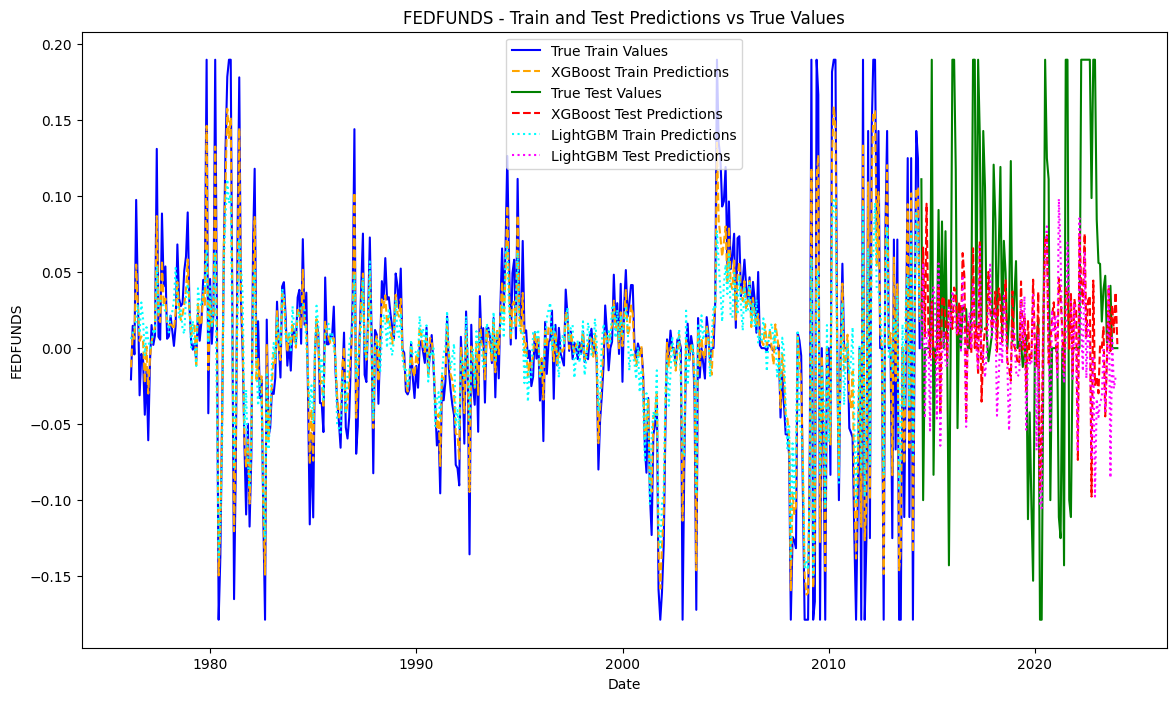

<Figure size 600x400 with 0 Axes>

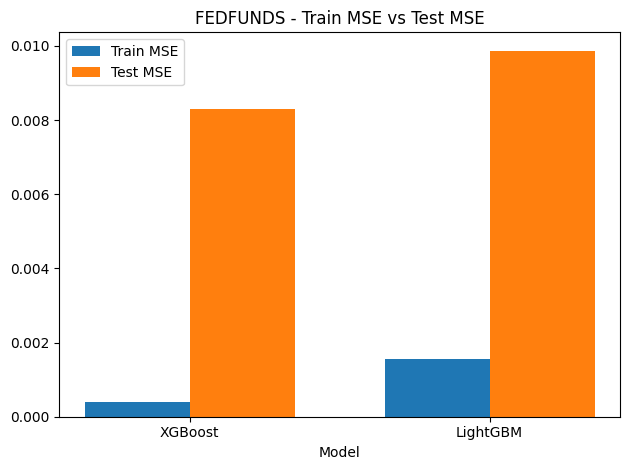

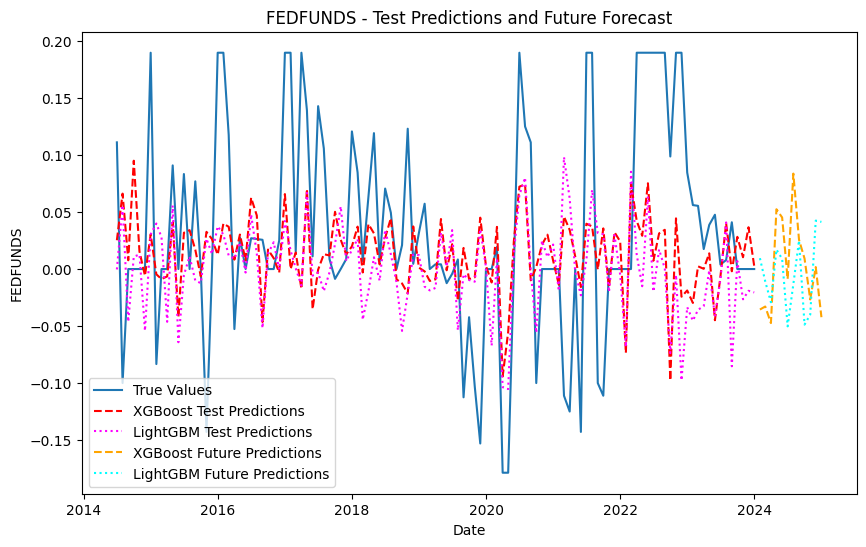

Processing target: GDP


ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [188]:
import os
import pandas as pd
import numpy as np
import ast
import re
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt

xgboost_params = {'max_depth': 9, 'learning_rate': 0.016810144010995204, 'n_estimators': 193, 'min_child_weight': 3, 'subsample': 0.5865511380196138, 'colsample_bytree': 0.9177433017782509, 'reg_alpha': 0.012513778476694921, 'reg_lambda': 8.577576991968611e-05}
lightgbm_params = {'num_leaves': 119, 'learning_rate': 0.0832469304666387, 'n_estimators': 71, 'max_depth': 3, 'min_child_samples': 18, 'subsample': 0.7402007213047204, 'colsample_bytree': 0.9405245932820381, 'reg_alpha': 0.000756445935013929, 'reg_lambda': 0.0002590470172405959}

# Function to compute MSE scores and return predictions for both models
def compute_mse_scores_with_reversal(X_train, X_test, y_train, y_test,transformations,target):
    # X_train_scaled = X_train.dropna()
    # X_test_scaled = X_test.dropna()
    display(f"X_train nan: {X_train.isna().sum()}")
    X_train_scaled = X_train
    X_test_scaled = X_test

    mse_scores = {'XGBoost': [], 'LightGBM': []}
    train_mse_scores = {'XGBoost': [], 'LightGBM': []}
    predictions = {'XGBoost_train': None, 'XGBoost_test': None, 'LightGBM_train': None, 'LightGBM_test': None}
    reversed_train_mse_scores = {'XGBoost': [], 'LightGBM': []}
    reversed_mse_scores =  {'XGBoost': [], 'LightGBM': []}
    models = {
        'XGBoost': XGBRegressor(**xgboost_params),
        'LightGBM': LGBMRegressor(verbosity=-1,**lightgbm_params)
    }

    # Original:
    # for model_name, model in models.items():
    #     model.fit(X_train_scaled, y_train)
    #     predictions[f'{model_name}_train'] = model.predict(X_train_scaled)
    #     predictions[f'{model_name}_test'] = model.predict(X_test_scaled)
    #     train_mse_scores[model_name] = mean_squared_error(y_train, predictions[f'{model_name}_train'])
    #     mse_scores[model_name] = mean_squared_error(y_test, predictions[f'{model_name}_test'])

    # New: def reverse_transformed_data(y_pred, y_test, transformations,target):
    for model_name, model in models.items():
        model.fit(X_train_scaled, y_train)
        y_pred_train = model.predict(X_train_scaled)
        y_pred_test = model.predict(X_test_scaled)

        predictions[f'{model_name}_train'] = y_pred_train
        predictions[f'{model_name}_test'] = y_pred_test
        predictions[f'{model_name}_train_reversed'],X_train_reversed = reverse_transformed_data(y_pred_train, y_train, transformations,target)
        predictions[f'{model_name}_test_reversed'],X_test_reversed = reverse_transformed_data(y_pred_test,y_test,transformations,target)
        train_mse_scores[model_name] = mean_squared_error(y_train, predictions[f'{model_name}_train'])
        mse_scores[model_name] = mean_squared_error(y_test, predictions[f'{model_name}_test'])
        reversed_train_mse_scores[model_name] = mean_squared_error(y_train, predictions[f'{model_name}_train_reversed'])
        reversed_mse_scores[model_name] =  mean_squared_error(y_test, predictions[f'{model_name}_test_reversed'])
    aggregated_mse = sum(mse_scores.values()) / len(mse_scores)
    aggregated_reversed_mse = sum(reversed_mse_scores.values()) / len(reversed_mse_scores)
    return mse_scores,reversed_mse_scores, train_mse_scores,reversed_train_mse_scores, aggregated_mse, predictions

# Iterate over all targets
targets = ['FEDFUNDS', 'GDP', 'CPIAUCSL', 'CUSR0000SAH1', 'CPILFESL', 'PCE', 'PRFI', 'PNFI', 'EXPGS', 'HOUST',  
           'DSPI', 'DGS5', 'DGS10', 'AAA', 'BAA', 'WTISPLC', 'IMPGS', 'FGCE', 'PCEPI', 
           'PCEPILFE', 'PAYEMS', 'UNRATE', 'INDPRO', 'CUMFNS', 'USREC', 'DGS2', 'GCE', 'GDPCTPI'] 

# targets = ['FEDFUNDS', 'GDP', 'CPIAUCSL', 'CUSR0000SAH1', 'CPILFESL',
#        'PCE', 'PRFI', 'PNFI', 'EXPGS', 'HOUST', 'DSPI', 'DGS2', 'DGS5', # New feature space, may not have lagged or engineered features ready
#        'DGS10', 'AAA', 'BAA', 'WTISPLC', 'IMPGS', 'GCE', 'FGCE', 'GDPCTPI',
#        'PCEPI', 'PCEPILFE', 'PAYEMS', 'UNRATE', 'INDPRO', 'CUMFNS', 'M1',
#        'M1V', 'M2', 'SP500', 'VIXCLS', 'BAMLH0A0HYM2', 'BAA10Y',
#        'BAMLC0A4CBBBEY', 'BAMLC0A1CAAAEY', 'T10YIE', 'T5YIE', 'DGS3MO',
#        'DGS30', 'BAA10YM', 'MORTGAGE30US', 'RSXFS', 'TCU', 'UMCSENT', 'NETEXP',
#        'PI', 'PPIACO']

features = targets
# Load data
processed_train_path = 'data/processed/train_transformed_combined.csv'
processed_test_path = 'data/processed/test_transformed_combined.csv'
tsfresh_train_path = 'data/tsfresh/train_combined_all_features_filled.csv'
tsfresh_test_path = 'data/tsfresh/test_combined_all_features_filled.csv'

train_combined = pd.read_csv(processed_train_path, index_col='Date', parse_dates=True)
test_combined = pd.read_csv(processed_test_path, index_col='Date', parse_dates=True)
tsfresh_features_train = pd.read_csv(tsfresh_train_path, index_col='Date', parse_dates=True)
tsfresh_features_test = pd.read_csv(tsfresh_test_path, index_col='Date', parse_dates=True)

for target in targets:
    print(f"Processing target: {target}")
    # Fix the Base DataFrame
    feature_space = pd.read_csv('feature_engineering_results_round2.csv')

    feature_space_mask = (feature_space == target).any(axis=1)
    feature_space_list = feature_space[feature_space_mask]['final_feature_space'].values.tolist()
    feature_space_series = pd.Series(feature_space_list)
    feature_space = feature_space_series.apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    flat_feature_space = [item for sublist in feature_space.tolist() for item in sublist] if any(isinstance(i, list) for i in feature_space.tolist()) else feature_space.tolist()
    train_combined_all_features_filed_tsfresh = pd.read_csv('data/tsfresh/train_combined_all_features_filled.csv', index_col='Date', parse_dates=True)
    test_combined_all_features_filed_tsfresh = pd.read_csv('data/tsfresh/test_combined_all_features_filled.csv', index_col='Date', parse_dates=True)
    X_train_tsfresh = train_combined_all_features_filed_tsfresh[flat_feature_space]
    X_test_tsfresh = test_combined_all_features_filed_tsfresh[flat_feature_space]
    X_train_tsfresh = X_train_tsfresh.rename(columns=lambda x: re.sub(str('""'), str('"'), x))
    X_test_tsfresh = X_test_tsfresh.rename(columns=lambda x: re.sub(str('""'), str('"'), x))
    X_train_tsfresh = X_train_tsfresh.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '', x))
    X_test_tsfresh = X_test_tsfresh.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '', x))
    # display(X_train_tsfresh.columns)
    # Fix the Lagged DataFrame
    top_lagged_features = pd.read_csv(r'C:\Users\nabounaser\OneDrive - Ejada Systems\EJADA\MacroEconomicAPI\top_features_combined_rmse_mse_results.csv')

    top_lagged_features_list = top_lagged_features.loc[top_lagged_features['target'] == target]['feature'].tolist()

    top_lagged_features = top_lagged_features[top_lagged_features['target'] == target]
    best_lagged_feature = top_lagged_features.sort_values(by='pct_improvement_mse', ascending=False).iloc[0]['feature']
    combined_lag_train = pd.read_csv('data/engineered/combined_lag_train.csv', index_col='Date', parse_dates=True)
    combined_lag_test = pd.read_csv('data/engineered/combined_lag_test.csv', index_col='Date', parse_dates=True)
    X_train_lagged = combined_lag_train[[best_lagged_feature]]
    X_test_lagged = combined_lag_test[[best_lagged_feature]]
    # display(X_train_lagged.columns)

    # Fix the Base DataFrame
    train_combined = pd.read_csv('data/processed/train_transformed_combined.csv', index_col='Date', parse_dates=True)
    test_combined = pd.read_csv('data/processed/test_transformed_combined.csv', index_col='Date', parse_dates=True)

    X_train = train_combined.drop(columns=[target])
    y_train = train_combined[target]
    X_test = test_combined.drop(columns=[target])
    y_test = test_combined[target]
    # display(X_train.columns)
    # Combine the three DataFrames
    # Combine the three DataFrames
    X_train_lagged = X_train_lagged.join(X_train_tsfresh, on=X_train_tsfresh.index) # EDIT: CHANGED TO .JOIN, FROM .CONCAT, FOR THE REALIGNMENT OF THE INDEX:
    X_train =  X_train.join(X_train_lagged,on=X_train_lagged.index)
    X_test_lagged = X_test_lagged.join(X_test_tsfresh,on=X_test_tsfresh.index)
    X_test = X_test.iloc[:X_test_lagged.shape[0]] # ADDED INDEXING, TO ALIGN X_TEST WITH X_TEST_LAGGED
    X_test = X_test.join(X_test_lagged,on=X_test_lagged.index)
    # make sure X_train and X_test have the same columns
    X_train = X_train[X_test.columns]
    # make sure X_train and y_train have the same number of samples/rows
    y_train.index = X_train.index
    y_train = y_train.loc[X_train.index]
    # make sure X_test and y_test have the same number of samples/rows
    y_test = y_test.iloc[:X_test.shape[0]]
    y_test.index = X_test.index
    # display(X_train.columns)
    # Compute MSE and plot predictions
    X_train = X_train.rename(columns=lambda x: re.sub(str('"'), str(''), x))
    X_test = X_test.rename(columns=lambda x: re.sub(str('"'), str(''), x))
    X_train = X_train.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '', x))
    X_test = X_test.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '', x))
    mse_scores, train_mse_scores, aggregated_mse, predictions = compute_mse_scores(X_train, X_test, y_train, y_test)
    print(f"Columns for {target}: {X_train.columns}")
    print(f"Train MSE for XGBoost: {train_mse_scores['XGBoost']}")
    print(f"Test MSE for XGBoost: {mse_scores['XGBoost']}")
    print(f"Train MSE for LightGBM: {train_mse_scores['LightGBM']}")
    print(f"Test MSE for LightGBM: {mse_scores['LightGBM']}")
    # Before plotting, making sure number of rows is consistent:
    train_combined = train_combined.iloc[:X_train.shape[0]]
    test_combined = test_combined.iloc[:X_test.shape[0]]
    
    # Plot train and test predictions
    plt.figure(figsize=(14, 8))
    plt.plot(train_combined.index, y_train, label='True Train Values', color='blue')
    plt.plot(train_combined.index, predictions['XGBoost_train'], label='XGBoost Train Predictions', linestyle='--', color='orange')
    display(f"test combined shape: {test_combined.shape}")
    display(f"train combined shape: {y_test.shape}")
    plt.plot(test_combined.index, y_test, label='True Test Values', color='green')
    plt.plot(test_combined.index, predictions['XGBoost_test'], label='XGBoost Test Predictions', linestyle='--', color='red')
    plt.plot(train_combined.index, predictions['LightGBM_train'], label='LightGBM Train Predictions', linestyle=':', color='cyan')
    plt.plot(test_combined.index, predictions['LightGBM_test'], label='LightGBM Test Predictions', linestyle=':', color='magenta')
    plt.title(f"{target} - Train and Test Predictions vs True Values")
    plt.legend()
    plt.xlabel("Date")
    plt.ylabel(target)
    plt.show()

    # Bar plot for Train MSE vs Test MSE
    plt.figure(figsize=(6, 4))
    models = ['XGBoost', 'LightGBM']
    train_mse = [train_mse_scores[model] for model in models]
    test_mse = [mse_scores[model] for model in models]
    x = np.arange(len(models))
    width = 0.35
    fig, ax = plt.subplots()
    rects1 = ax.bar(x - width/2, train_mse, width, label='Train MSE')
    rects2 = ax.bar(x + width/2, test_mse, width, label='Test MSE')

    ax.set_xlabel('Model')
    ax.set_title(f'{target} - Train MSE vs Test MSE')
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.legend()

    fig.tight_layout()
    plt.show()

    # Forecast into the future
    future_steps = 12  # Number of steps to forecast
    X_last_known = X_test.iloc[-1, :].values.reshape(1, -1)
    
    # Forecast with XGBoost
    future_predictions_xgb = []
    model_xgb = XGBRegressor()
    model_xgb.fit(X_train, y_train)
    
    for step in range(future_steps):
        pred = model_xgb.predict(X_last_known)
        future_predictions_xgb.append(pred)
        X_last_known = np.roll(X_last_known, -1)
        X_last_known[0, -1] = pred

    # Forecast with LightGBM
    future_predictions_lgb = []
    model_lgb = LGBMRegressor(verbosity=-1)
    model_lgb.fit(X_train, y_train)
    
    for step in range(future_steps):
        pred = model_lgb.predict(X_last_known)
        future_predictions_lgb.append(pred)
        X_last_known = np.roll(X_last_known, -1)
        X_last_known[0, -1] = pred

    plt.figure(figsize=(10, 6))
    plt.plot(test_combined.index, y_test, label='True Values')
    plt.plot(test_combined.index, predictions['XGBoost_test'], label='XGBoost Test Predictions', linestyle='--', color='red')
    plt.plot(test_combined.index, predictions['LightGBM_test'], label='LightGBM Test Predictions', linestyle=':', color='magenta')
    plt.plot(pd.date_range(start=test_combined.index[-1], periods=future_steps+1, freq='M')[1:], future_predictions_xgb, label='XGBoost Future Predictions', linestyle='--', color='orange')
    plt.plot(pd.date_range(start=test_combined.index[-1], periods=future_steps+1, freq='M')[1:], future_predictions_lgb, label='LightGBM Future Predictions', linestyle=':', color='cyan')
    plt.title(f"{target} - Test Predictions and Future Forecast")
    plt.xlabel("Date")
    plt.ylabel(target)
    plt.legend()
    plt.show()




# Improved Forecast: Reversing the Y-Predictions

In this notebook, I will show you how to improve the forecast of the time series data by reversing the predictions. This is a simple trick that can be used to improve the forecast of the time series data.

In [229]:
import os
import pandas as pd
import numpy as np
import ast
import re
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt

xgboost_params = {'max_depth': 9, 'learning_rate': 0.016810144010995204, 'n_estimators': 193, 'min_child_weight': 3, 'subsample': 0.5865511380196138, 'colsample_bytree': 0.9177433017782509, 'reg_alpha': 0.012513778476694921, 'reg_lambda': 8.577576991968611e-05}
lightgbm_params = {'num_leaves': 119, 'learning_rate': 0.0832469304666387, 'n_estimators': 71, 'max_depth': 3, 'min_child_samples': 18, 'subsample': 0.7402007213047204, 'colsample_bytree': 0.9405245932820381, 'reg_alpha': 0.000756445935013929, 'reg_lambda': 0.0002590470172405959}

# Function to compute MSE scores and return predictions for both models
def compute_mse_scores(X_train, X_test, y_train, y_test):
    # X_train_scaled = X_train.dropna()
    # X_test_scaled = X_test.dropna()
    display(f"X_train nan: {X_train.isna().sum()}")
    X_train_scaled = X_train
    X_test_scaled = X_test

    mse_scores = {'XGBoost': [], 'LightGBM': []}
    train_mse_scores = {'XGBoost': [], 'LightGBM': []}
    predictions = {'XGBoost_train': None, 'XGBoost_test': None, 'LightGBM_train': None, 'LightGBM_test': None}

    models = {
        'XGBoost': XGBRegressor(**xgboost_params),
        'LightGBM': LGBMRegressor(verbosity=-1,**lightgbm_params)
    }

    for model_name, model in models.items():
        model.fit(X_train_scaled, y_train)
        predictions[f'{model_name}_train'] = model.predict(X_train_scaled)
        predictions[f'{model_name}_test'] = model.predict(X_test_scaled)
        train_mse_scores[model_name] = mean_squared_error(y_train, predictions[f'{model_name}_train'])
        mse_scores[model_name] = mean_squared_error(y_test, predictions[f'{model_name}_test'])

    aggregated_mse = sum(mse_scores.values()) / len(mse_scores)
    return mse_scores, train_mse_scores, aggregated_mse, predictions

# Iterate over all targets
targets = ['FEDFUNDS', 'GDP', 'CPIAUCSL', 'CUSR0000SAH1', 'CPILFESL', 'PCE', 'PRFI', 'PNFI', 'EXPGS', 'HOUST',  
           'DSPI', 'DGS5', 'DGS10', 'AAA', 'BAA', 'WTISPLC', 'IMPGS', 'FGCE', 'PCEPI', 
           'PCEPILFE', 'PAYEMS', 'UNRATE', 'INDPRO', 'CUMFNS', 'USREC', 'DGS2', 'GCE', 'GDPCTPI'] 

# targets = ['FEDFUNDS', 'GDP', 'CPIAUCSL', 'CUSR0000SAH1', 'CPILFESL',
#        'PCE', 'PRFI', 'PNFI', 'EXPGS', 'HOUST', 'DSPI', 'DGS2', 'DGS5', # New feature space, may not have lagged or engineered features ready
#        'DGS10', 'AAA', 'BAA', 'WTISPLC', 'IMPGS', 'GCE', 'FGCE', 'GDPCTPI',
#        'PCEPI', 'PCEPILFE', 'PAYEMS', 'UNRATE', 'INDPRO', 'CUMFNS', 'M1',
#        'M1V', 'M2', 'SP500', 'VIXCLS', 'BAMLH0A0HYM2', 'BAA10Y',
#        'BAMLC0A4CBBBEY', 'BAMLC0A1CAAAEY', 'T10YIE', 'T5YIE', 'DGS3MO',
#        'DGS30', 'BAA10YM', 'MORTGAGE30US', 'RSXFS', 'TCU', 'UMCSENT', 'NETEXP',
#        'PI', 'PPIACO']

features = targets
# Load data
processed_train_path = 'data/processed/train_transformed_combined.csv'
processed_test_path = 'data/processed/test_transformed_combined.csv'
tsfresh_train_path = 'data/tsfresh/train_combined_all_features_filled.csv'
tsfresh_test_path = 'data/tsfresh/test_combined_all_features_filled.csv'

train_combined = pd.read_csv(processed_train_path, index_col='Date', parse_dates=True)
test_combined = pd.read_csv(processed_test_path, index_col='Date', parse_dates=True)
tsfresh_features_train = pd.read_csv(tsfresh_train_path, index_col='Date', parse_dates=True)
tsfresh_features_test = pd.read_csv(tsfresh_test_path, index_col='Date', parse_dates=True)
transformations = ['impute','deflate','log','scale','pct_change','adf']
for target in targets:
    print(f"Processing target: {target}")
    # Fix the Base DataFrame
    feature_space = pd.read_csv('feature_engineering_results_round2.csv')

    feature_space_mask = (feature_space == target).any(axis=1)
    feature_space_list = feature_space[feature_space_mask]['final_feature_space'].values.tolist()
    feature_space_series = pd.Series(feature_space_list)
    feature_space = feature_space_series.apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    flat_feature_space = [item for sublist in feature_space.tolist() for item in sublist] if any(isinstance(i, list) for i in feature_space.tolist()) else feature_space.tolist()
    train_combined_all_features_filed_tsfresh = pd.read_csv('data/tsfresh/train_combined_all_features_filled.csv', index_col='Date', parse_dates=True)
    test_combined_all_features_filed_tsfresh = pd.read_csv('data/tsfresh/test_combined_all_features_filled.csv', index_col='Date', parse_dates=True)
    X_train_tsfresh = train_combined_all_features_filed_tsfresh[flat_feature_space]
    X_test_tsfresh = test_combined_all_features_filed_tsfresh[flat_feature_space]
    X_train_tsfresh = X_train_tsfresh.rename(columns=lambda x: re.sub(str('""'), str('"'), x))
    X_test_tsfresh = X_test_tsfresh.rename(columns=lambda x: re.sub(str('""'), str('"'), x))
    X_train_tsfresh = X_train_tsfresh.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '', x))
    X_test_tsfresh = X_test_tsfresh.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '', x))
    # display(X_train_tsfresh.columns)
    # Fix the Lagged DataFrame
    top_lagged_features = pd.read_csv(r'C:\Users\nabounaser\OneDrive - Ejada Systems\EJADA\MacroEconomicAPI\top_features_combined_rmse_mse_results.csv')

    top_lagged_features_list = top_lagged_features.loc[top_lagged_features['target'] == target]['feature'].tolist()

    top_lagged_features = top_lagged_features[top_lagged_features['target'] == target]
    best_lagged_feature = top_lagged_features.sort_values(by='pct_improvement_mse', ascending=False).iloc[0]['feature']
    combined_lag_train = pd.read_csv('data/engineered/combined_lag_train.csv', index_col='Date', parse_dates=True)
    combined_lag_test = pd.read_csv('data/engineered/combined_lag_test.csv', index_col='Date', parse_dates=True)
    X_train_lagged = combined_lag_train[[best_lagged_feature]]
    X_test_lagged = combined_lag_test[[best_lagged_feature]]
    # display(X_train_lagged.columns)

    # Fix the Base DataFrame
    train_combined = pd.read_csv('data/processed/train_transformed_combined.csv', index_col='Date', parse_dates=True)
    test_combined = pd.read_csv('data/processed/test_transformed_combined.csv', index_col='Date', parse_dates=True)

    X_train = train_combined.drop(columns=[target])
    y_train = train_combined[target]
    X_test = test_combined.drop(columns=[target])
    y_test = test_combined[target]
    # display(X_train.columns)
    # Combine the three DataFrames
    # Combine the three DataFrames
    X_train_lagged = X_train_lagged.join(X_train_tsfresh, on=X_train_tsfresh.index) # EDIT: CHANGED TO .JOIN, FROM .CONCAT, FOR THE REALIGNMENT OF THE INDEX:
    X_train =  X_train.join(X_train_lagged,on=X_train_lagged.index)
    X_test_lagged = X_test_lagged.join(X_test_tsfresh,on=X_test_tsfresh.index)
    X_test = X_test.iloc[:X_test_lagged.shape[0]] # ADDED INDEXING, TO ALIGN X_TEST WITH X_TEST_LAGGED
    X_test = X_test.join(X_test_lagged,on=X_test_lagged.index)
    # make sure X_train and X_test have the same columns
    X_train = X_train[X_test.columns]
    # make sure X_train and y_train have the same number of samples/rows
    y_train.index = X_train.index
    y_train = y_train.loc[X_train.index]
    # make sure X_test and y_test have the same number of samples/rows
    y_test = y_test.iloc[:X_test.shape[0]]
    y_test.index = X_test.index
    # display(X_train.columns)
    # Compute MSE and plot predictions
    X_train = X_train.rename(columns=lambda x: re.sub(str('"'), str(''), x))
    X_test = X_test.rename(columns=lambda x: re.sub(str('"'), str(''), x))
    X_train = X_train.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '', x))
    X_test = X_test.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '', x))

    mse_scores,reversed_mse_scores, train_mse_scores,reversed_train_mse_scores, aggregated_mse, predictions = compute_mse_scores_with_reversal(X_train, X_test, y_train, y_test,transformations,target)
    # TEMPORARY FIX -- TO QUICKLY SWITCH THE REVERSED PREDICTIONS AND RESULTS WITH THE NORMAL ONES:
    mse_scores = reversed_mse_scores
    train_mse_scores = reversed_train_mse_scores
    # Also, we will bring back the raw_data, which is at the correct scale:
    raw = pd.read_csv('data/raw/raw_data.csv',index_col='Date',parse_dates=True)
    y_raw = raw[target]
    display("first")
    display(y_raw)
    y_raw_test_combined = y_raw.iloc[y_test.shape[0]:]
    display("NOOOW")
    display(y_raw_test_combined)
    y_raw_train_combined = y_raw.iloc[:y_train.shape[0]]
    y_raw_test_combined.index = y_test.index
    # display(f"y_train shape: {y_train.shape}")
    # display(f"y_raw_train_combined.shape : {y_raw_train_combined.shape}")
    y_raw_train_combined.index = y_train.index
    y_train = y_raw_train_combined
    y_test = y_raw_test_combined


    ################ WARNING, ABOVE IS A TEMPORARY FIX#####################
    print(f"Columns for {target}: {X_train.columns}")
    print(f"Train MSE for XGBoost: {train_mse_scores['XGBoost']}")
    print(f"Test MSE for XGBoost: {mse_scores['XGBoost']}")
    print(f"Train MSE for LightGBM: {train_mse_scores['LightGBM']}")
    print(f"Test MSE for LightGBM: {mse_scores['LightGBM']}")
    # Before plotting, making sure number of rows is consistent:
    train_combined = train_combined.iloc[:X_train.shape[0]]
    test_combined = test_combined.iloc[:X_test.shape[0]]
    
    # Plot train and test predictions
    plt.figure(figsize=(14, 8))
    plt.plot(train_combined.index, y_train, label='True Train Values', color='blue')
    plt.plot(train_combined.index, predictions['XGBoost_train'], label='XGBoost Train Predictions', linestyle='--', color='orange')
    display(f"test combined shape: {test_combined.shape}")
    display(f"train combined shape: {y_test.shape}")
    plt.plot(test_combined.index, y_test, label='True Test Values', color='green')
    plt.plot(test_combined.index, predictions['XGBoost_test'], label='XGBoost Test Predictions', linestyle='--', color='red')
    plt.plot(train_combined.index, predictions['LightGBM_train'], label='LightGBM Train Predictions', linestyle=':', color='cyan')
    plt.plot(test_combined.index, predictions['LightGBM_test'], label='LightGBM Test Predictions', linestyle=':', color='magenta')
    plt.title(f"{target} - Train and Test Predictions vs True Values")
    plt.legend()
    plt.xlabel("Date")
    plt.ylabel(target)
    plt.show()

    # Bar plot for Train MSE vs Test MSE
    plt.figure(figsize=(6, 4))
    models = ['XGBoost', 'LightGBM']
    train_mse = [train_mse_scores[model] for model in models]
    test_mse = [mse_scores[model] for model in models]
    x = np.arange(len(models))
    width = 0.35
    fig, ax = plt.subplots()
    rects1 = ax.bar(x - width/2, train_mse, width, label='Train MSE')
    rects2 = ax.bar(x + width/2, test_mse, width, label='Test MSE')

    ax.set_xlabel('Model')
    ax.set_title(f'{target} - Train MSE vs Test MSE')
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.legend()

    fig.tight_layout()
    plt.show()

    # Forecast into the future
    future_steps = 12  # Number of steps to forecast
    X_last_known = X_test.iloc[-1, :].values.reshape(1, -1)
    
    # Forecast with XGBoost
    future_predictions_xgb = []
    model_xgb = XGBRegressor()
    model_xgb.fit(X_train, y_train)
    
    for step in range(future_steps):
        pred = model_xgb.predict(X_last_known)
        future_predictions_xgb.append(pred)
        X_last_known = np.roll(X_last_known, -1)
        X_last_known[0, -1] = pred

    # Forecast with LightGBM
    future_predictions_lgb = []
    model_lgb = LGBMRegressor(verbosity=-1)
    model_lgb.fit(X_train, y_train)
    
    for step in range(future_steps):
        pred = model_lgb.predict(X_last_known)
        future_predictions_lgb.append(pred)
        X_last_known = np.roll(X_last_known, -1)
        X_last_known[0, -1] = pred

    plt.figure(figsize=(10, 6))
    plt.plot(test_combined.index, y_test, label='True Values')
    plt.plot(test_combined.index, predictions['XGBoost_test'], label='XGBoost Test Predictions', linestyle='--', color='red')
    plt.plot(test_combined.index, predictions['LightGBM_test'], label='LightGBM Test Predictions', linestyle=':', color='magenta')
    plt.plot(pd.date_range(start=test_combined.index[-1], periods=future_steps+1, freq='M')[1:], future_predictions_xgb, label='XGBoost Future Predictions', linestyle='--', color='orange')
    plt.plot(pd.date_range(start=test_combined.index[-1], periods=future_steps+1, freq='M')[1:], future_predictions_lgb, label='LightGBM Future Predictions', linestyle=':', color='cyan')
    plt.title(f"{target} - Test Predictions and Future Forecast")
    plt.xlabel("Date")
    plt.ylabel(target)
    plt.legend()
    plt.show()




Processing target: FEDFUNDS


'X_train nan: GDP                                                               0\nCPIAUCSL                                                          0\nCUSR0000SAH1                                                      0\nCPILFESL                                                          0\nPCE                                                               0\nPRFI                                                              0\nPNFI                                                              0\nEXPGS                                                             0\nHOUST                                                             0\nDSPI                                                              0\nDGS2                                                              0\nDGS5                                                              0\nDGS10                                                             0\nAAA                                                               0\nBAA                 

Arrived to 'log' in applying log transformations:
columns y_test: Date
1976-02-29    1.516957
1976-03-31    1.580153
1976-04-30    1.546396
1976-05-31    1.728832
1976-06-30    1.618279
                ...   
2014-01-31    1.233172
2014-02-28    1.553813
2014-03-31    1.810224
2014-04-30    1.778173
2014-05-31    1.553813
Length: 460, dtype: float64
COMPLETED 'LOG'
Arrived to 'log' in applying log transformations:
columns y_test: Date
2014-06-30    1.753244
2014-07-31    1.374326
2014-08-31    1.553813
2014-09-30    1.553813
2014-10-31    1.553813
                ...   
2023-08-31    1.627431
2023-09-30    1.553813
2023-10-31    1.553813
2023-11-30    1.553813
2023-12-31    1.553813
Length: 115, dtype: float64
COMPLETED 'LOG'
Arrived to 'log' in applying log transformations:
columns y_test: Date
1976-02-29    1.516957
1976-03-31    1.580153
1976-04-30    1.546396
1976-05-31    1.728832
1976-06-30    1.618279
                ...   
2014-01-31    1.233172
2014-02-28    1.553813
2014-03-3

'first'

Date
2003-01-31    1.24
2003-02-28    1.26
2003-03-31    1.25
2003-04-30    1.26
2003-05-31    1.26
              ... 
2024-01-31    5.33
2024-02-29    5.33
2024-03-31    5.33
2024-04-30    5.33
2024-05-31    5.33
Name: FEDFUNDS, Length: 257, dtype: float64

'NOOOW'

Date
2012-08-31    0.13
2012-09-30    0.14
2012-10-31    0.16
2012-11-30    0.16
2012-12-31    0.16
              ... 
2024-01-31    5.33
2024-02-29    5.33
2024-03-31    5.33
2024-04-30    5.33
2024-05-31    5.33
Name: FEDFUNDS, Length: 142, dtype: float64

ValueError: Length mismatch: Expected axis has 142 elements, new values have 115 elements

In [217]:
display(y_test)

Date
2014-06-30    0.004007
2014-07-31    0.002950
2014-08-31    0.002793
2014-09-30    0.001665
2014-10-31    0.001875
                ...   
2023-08-31    0.000200
2023-09-30    0.000294
2023-10-31    0.002510
2023-11-30    0.001440
2023-12-31    0.001219
Name: GDP, Length: 115, dtype: float64